In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.regularizers import l2

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

In [2]:
PROCESSED_DIR = "processed_data"

X_mfcc = np.load(os.path.join(PROCESSED_DIR, "X_rnn_mfcc.npy"), allow_pickle=True)
y = np.load(os.path.join(PROCESSED_DIR, "y_labels.npy"))
folds = np.load(os.path.join(PROCESSED_DIR, "folds.npy"))

n_classes = len(np.unique(y))
print("Número de amostras:", len(X_mfcc))
print("Número de classes:", n_classes)

Número de amostras: 34928
Número de classes: 10


In [3]:
# X_mfcc[i] tem formato (n_mfcc, T)
n_mfcc = X_mfcc[0].shape[0]
max_len = max(seq.shape[1] for seq in X_mfcc)

n_samples = len(X_mfcc)
X_padded = np.zeros((n_samples, max_len, n_mfcc), dtype=np.float32)

for i, seq in enumerate(X_mfcc):
    T = min(seq.shape[1], max_len)
    # seq: (n_mfcc, T)  ->  (T, n_mfcc)
    X_padded[i, :T, :] = seq[:, :T].T

# Agora formatar para CNN: (samples, time, n_mfcc, channels)
X_cnn = X_padded[..., np.newaxis]

input_shape = X_cnn.shape[1:]
print("Input shape para CNN:", input_shape)

Input shape para CNN: (173, 40, 1)


In [4]:
learning_rate = 1e-3
dropout_rate = 0.5
l2_reg = 1e-4
batch_size = 32
epochs = 50

In [5]:
def cnn_model(input_shape, n_classes,
              dropout_rate=dropout_rate,
              learning_rate=learning_rate,
              l2_reg=l2_reg):
    
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same",
                      activation="relu",
                      kernel_regularizer=l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(64, (3, 3), padding="same",
                      activation="relu",
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(128, (3, 3), padding="same",
                      activation="relu",
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Resume tudo num vetor
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=l2(l2_reg))(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [6]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

callback_list = [early_stop, reduce_lr]

In [7]:
class_names = [
    "air-conditioner",
    "car-horn",
    "children-playing",
    "dog-bark",
    "drilling",
    "engine-idling",
    "gun-shot",
    "jackhammer",
    "siren",
    "street-music",
]

In [8]:
def plot_graphs(history, y_true, y_pred, class_labels):
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    # Accuracy
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')

    # Loss
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=axs[2])
    axs[2].set_title('Confusion Matrix')
    axs[2].set_xlabel('Predicted')
    axs[2].set_ylabel('True')

    plt.tight_layout()
    plt.show()




=== Training fold 1 (val fold 2) ===
Epoch 1/50


872/872 [==============================] - 87s 98ms/step - loss: 1.7053 - accuracy: 0.3934 - val_loss: 1.8330 - val_accuracy: 0.3578 - lr: 0.0010
Epoch 2/50
872/872 [==============================] - 87s 99ms/step - loss: 1.3318 - accuracy: 0.5518 - val_loss: 1.5901 - val_accuracy: 0.4260 - lr: 0.0010
Epoch 3/50
872/872 [==============================] - 92s 106ms/step - loss: 1.2149 - accuracy: 0.5954 - val_loss: 1.6999 - val_accuracy: 0.4189 - lr: 0.0010
Epoch 4/50
872/872 [==============================] - 90s 104ms/step - loss: 1.1567 - accuracy: 0.6198 - val_loss: 1.1847 - val_accuracy: 0.5833 - lr: 0.0010
Epoch 5/50
872/872 [==============================] - 90s 103ms/step - loss: 1.1170 - accuracy: 0.6349 - val_loss: 1.2230 - val_accuracy: 0.5926 - lr: 0.0010
Epoch 6/50
872/872 [==============================] - 89s 102ms/step - loss: 1.0853 - accuracy: 0.6467 - val_loss: 1.3118 - val_accuracy: 0.5543 - lr: 0.0010
Epoch 7/50
8

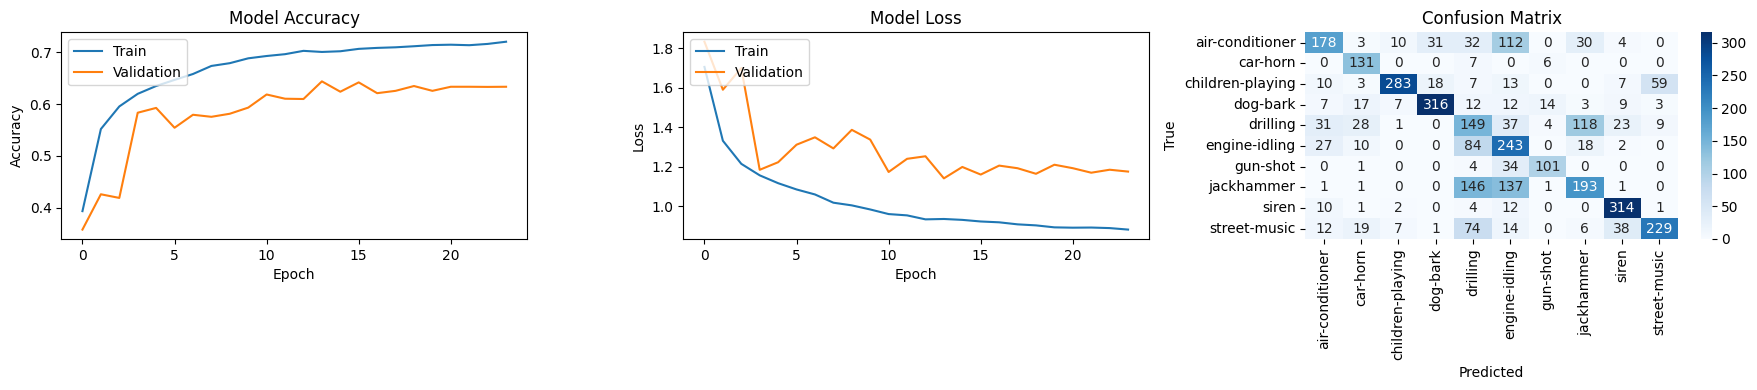

Fold 1 accuracy: 0.6120

=== Training fold 2 (val fold 3) ===
Epoch 1/50
865/865 [==============================] - 86s 98ms/step - loss: 1.6775 - accuracy: 0.4080 - val_loss: 1.9368 - val_accuracy: 0.3735 - lr: 0.0010
Epoch 2/50
865/865 [==============================] - 86s 99ms/step - loss: 1.3081 - accuracy: 0.5575 - val_loss: 1.6471 - val_accuracy: 0.4786 - lr: 0.0010
Epoch 3/50
865/865 [==============================] - 81s 93ms/step - loss: 1.2034 - accuracy: 0.6011 - val_loss: 1.8928 - val_accuracy: 0.4478 - lr: 0.0010
Epoch 4/50
865/865 [==============================] - 81s 94ms/step - loss: 1.1450 - accuracy: 0.6199 - val_loss: 1.6164 - val_accuracy: 0.4938 - lr: 0.0010
Epoch 5/50
865/865 [==============================] - 82s 95ms/step - loss: 1.0944 - accuracy: 0.6451 - val_loss: 1.3823 - val_accuracy: 0.5351 - lr: 0.0010
Epoch 6/50
865/865 [==============================] - 83s 96ms/step - loss: 1.0719 - accuracy: 0.6521 - val_loss: 1.2895 - val_accuracy: 0.5697 - lr: 0.0

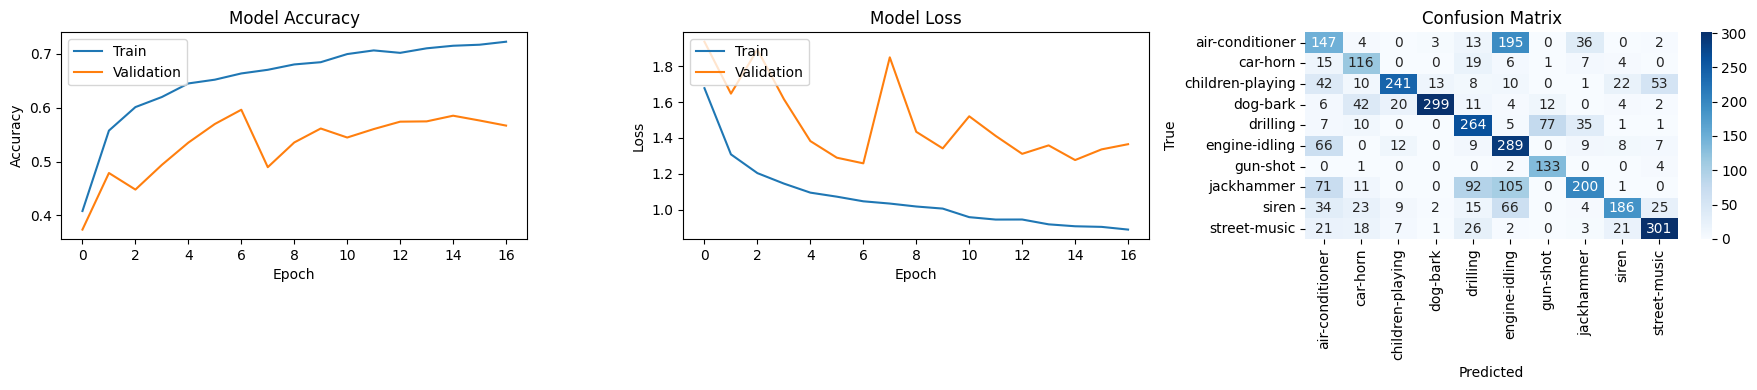

Fold 2 accuracy: 0.6126

=== Training fold 3 (val fold 4) ===
Epoch 1/50
853/853 [==============================] - 87s 100ms/step - loss: 1.7121 - accuracy: 0.3860 - val_loss: 1.6278 - val_accuracy: 0.4149 - lr: 0.0010
Epoch 2/50
853/853 [==============================] - 86s 101ms/step - loss: 1.3533 - accuracy: 0.5411 - val_loss: 1.5176 - val_accuracy: 0.5071 - lr: 0.0010
Epoch 3/50
853/853 [==============================] - 83s 97ms/step - loss: 1.2280 - accuracy: 0.5887 - val_loss: 1.5207 - val_accuracy: 0.5098 - lr: 0.0010
Epoch 4/50
853/853 [==============================] - 83s 97ms/step - loss: 1.1604 - accuracy: 0.6178 - val_loss: 1.5459 - val_accuracy: 0.5354 - lr: 0.0010
Epoch 5/50
853/853 [==============================] - 82s 96ms/step - loss: 1.1229 - accuracy: 0.6327 - val_loss: 1.2773 - val_accuracy: 0.5884 - lr: 0.0010
Epoch 6/50
853/853 [==============================] - 81s 95ms/step - loss: 1.0915 - accuracy: 0.6458 - val_loss: 1.4086 - val_accuracy: 0.5566 - lr: 0

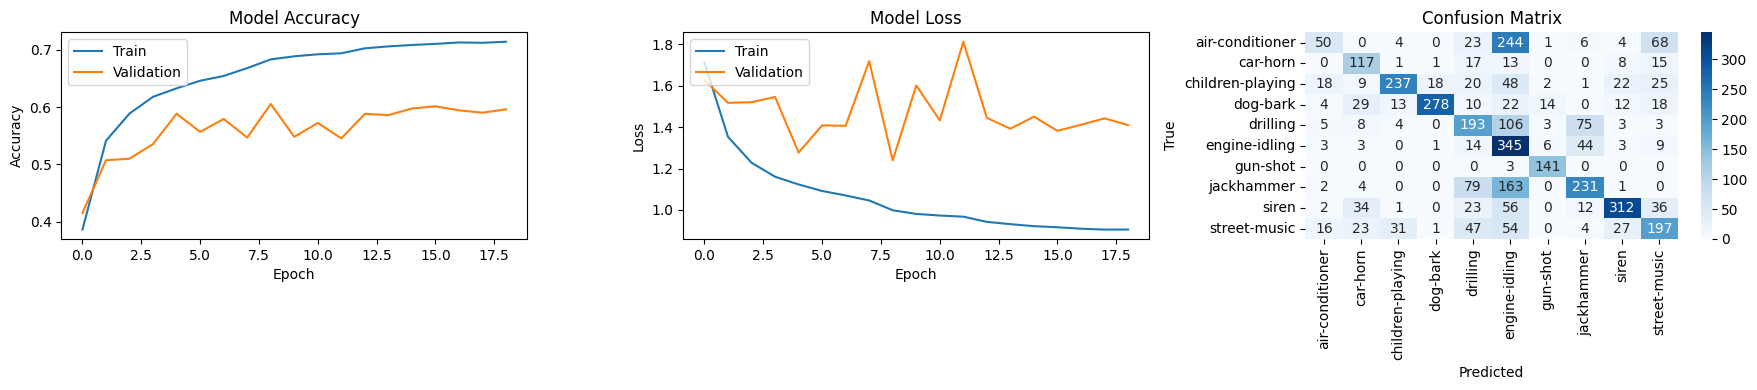

Fold 3 accuracy: 0.5678

=== Training fold 4 (val fold 5) ===
Epoch 1/50
851/851 [==============================] - 81s 93ms/step - loss: 1.6803 - accuracy: 0.4042 - val_loss: 1.7362 - val_accuracy: 0.4199 - lr: 0.0010
Epoch 2/50
851/851 [==============================] - 83s 98ms/step - loss: 1.3453 - accuracy: 0.5423 - val_loss: 1.7915 - val_accuracy: 0.4685 - lr: 0.0010
Epoch 3/50
851/851 [==============================] - 80s 94ms/step - loss: 1.2330 - accuracy: 0.5836 - val_loss: 1.6606 - val_accuracy: 0.4947 - lr: 0.0010
Epoch 4/50
851/851 [==============================] - 82s 96ms/step - loss: 1.1797 - accuracy: 0.6085 - val_loss: 1.8507 - val_accuracy: 0.4824 - lr: 0.0010
Epoch 5/50
851/851 [==============================] - 82s 97ms/step - loss: 1.1376 - accuracy: 0.6264 - val_loss: 1.3234 - val_accuracy: 0.5710 - lr: 0.0010
Epoch 6/50
851/851 [==============================] - 84s 99ms/step - loss: 1.1082 - accuracy: 0.6363 - val_loss: 1.8499 - val_accuracy: 0.4979 - lr: 0.0

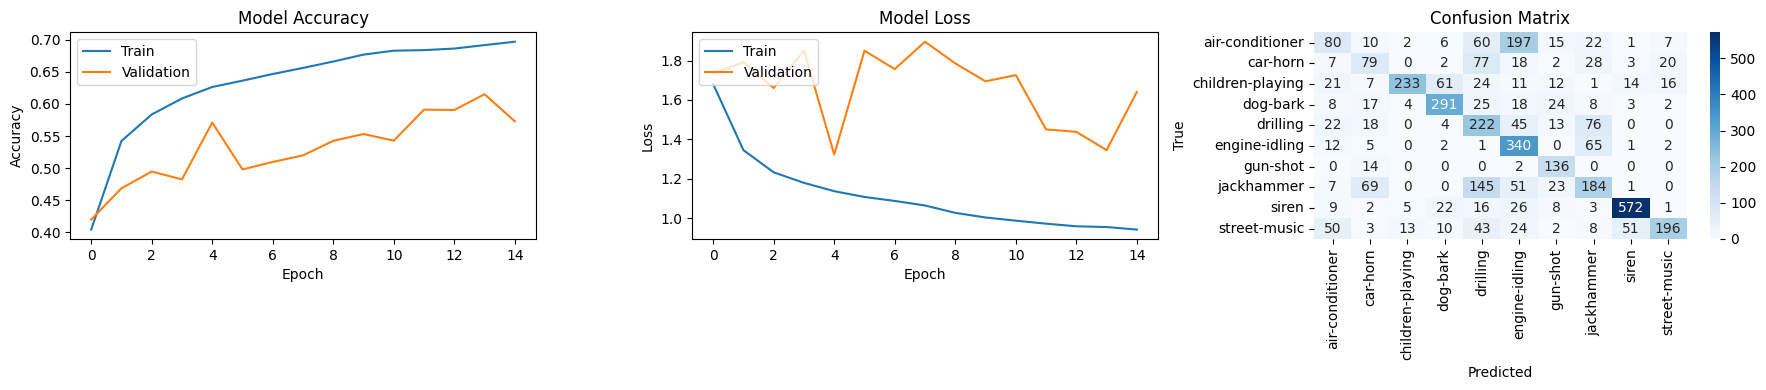

Fold 4 accuracy: 0.5891

=== Training fold 5 (val fold 6) ===
Epoch 1/50
872/872 [==============================] - 90s 102ms/step - loss: 1.6861 - accuracy: 0.3987 - val_loss: 2.2944 - val_accuracy: 0.2822 - lr: 0.0010
Epoch 2/50
872/872 [==============================] - 94s 108ms/step - loss: 1.3298 - accuracy: 0.5499 - val_loss: 1.8478 - val_accuracy: 0.4754 - lr: 0.0010
Epoch 3/50
872/872 [==============================] - 94s 108ms/step - loss: 1.2229 - accuracy: 0.5899 - val_loss: 1.6769 - val_accuracy: 0.4936 - lr: 0.0010
Epoch 4/50
872/872 [==============================] - 94s 108ms/step - loss: 1.1610 - accuracy: 0.6175 - val_loss: 1.5647 - val_accuracy: 0.5243 - lr: 0.0010
Epoch 5/50
872/872 [==============================] - 94s 108ms/step - loss: 1.1132 - accuracy: 0.6350 - val_loss: 1.5405 - val_accuracy: 0.5173 - lr: 0.0010
Epoch 6/50
872/872 [==============================] - 97s 111ms/step - loss: 1.0825 - accuracy: 0.6461 - val_loss: 1.5782 - val_accuracy: 0.5495 - l

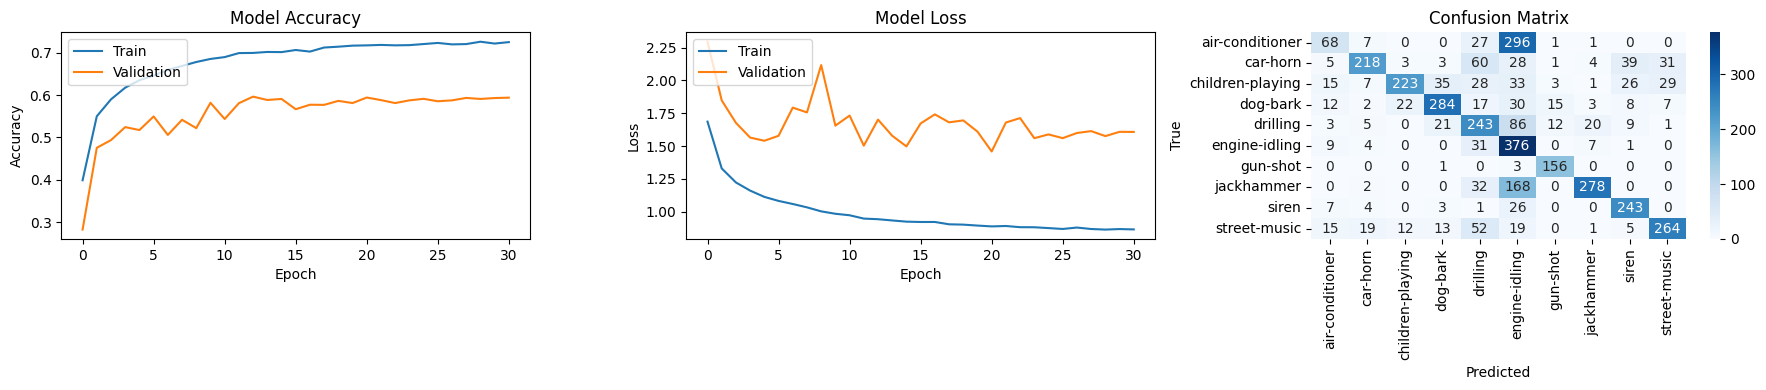

Fold 5 accuracy: 0.6285

=== Training fold 6 (val fold 7) ===
Epoch 1/50
884/884 [==============================] - 97s 108ms/step - loss: 1.6855 - accuracy: 0.4000 - val_loss: 1.9579 - val_accuracy: 0.3756 - lr: 0.0010
Epoch 2/50
884/884 [==============================] - 93s 106ms/step - loss: 1.3247 - accuracy: 0.5472 - val_loss: 1.7000 - val_accuracy: 0.4785 - lr: 0.0010
Epoch 3/50
884/884 [==============================] - 94s 106ms/step - loss: 1.2175 - accuracy: 0.5907 - val_loss: 2.2496 - val_accuracy: 0.4376 - lr: 0.0010
Epoch 4/50
884/884 [==============================] - 94s 107ms/step - loss: 1.1575 - accuracy: 0.6193 - val_loss: 1.6121 - val_accuracy: 0.5146 - lr: 0.0010
Epoch 5/50
884/884 [==============================] - 94s 106ms/step - loss: 1.1224 - accuracy: 0.6335 - val_loss: 1.5864 - val_accuracy: 0.5430 - lr: 0.0010
Epoch 6/50
884/884 [==============================] - 94s 106ms/step - loss: 1.0920 - accuracy: 0.6431 - val_loss: 2.0946 - val_accuracy: 0.5087 - l

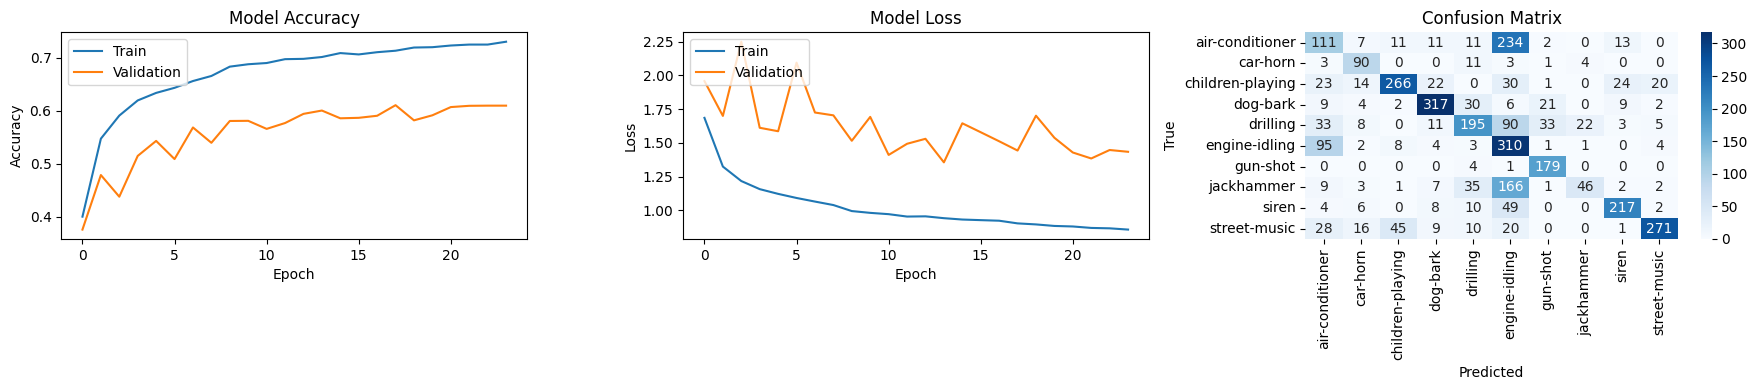

Fold 6 accuracy: 0.6081

=== Training fold 7 (val fold 8) ===
Epoch 1/50
886/886 [==============================] - 94s 105ms/step - loss: 1.6603 - accuracy: 0.4012 - val_loss: 1.9778 - val_accuracy: 0.3852 - lr: 0.0010
Epoch 2/50
886/886 [==============================] - 99s 112ms/step - loss: 1.3148 - accuracy: 0.5466 - val_loss: 1.9756 - val_accuracy: 0.4417 - lr: 0.0010
Epoch 3/50
886/886 [==============================] - 98s 110ms/step - loss: 1.2153 - accuracy: 0.5889 - val_loss: 2.3577 - val_accuracy: 0.4342 - lr: 0.0010
Epoch 4/50
886/886 [==============================] - 100s 112ms/step - loss: 1.1505 - accuracy: 0.6162 - val_loss: 1.8723 - val_accuracy: 0.4705 - lr: 0.0010
Epoch 5/50
886/886 [==============================] - 97s 109ms/step - loss: 1.0982 - accuracy: 0.6375 - val_loss: 1.6091 - val_accuracy: 0.5490 - lr: 0.0010
Epoch 6/50
886/886 [==============================] - 94s 106ms/step - loss: 1.0712 - accuracy: 0.6489 - val_loss: 1.6765 - val_accuracy: 0.5372 - 

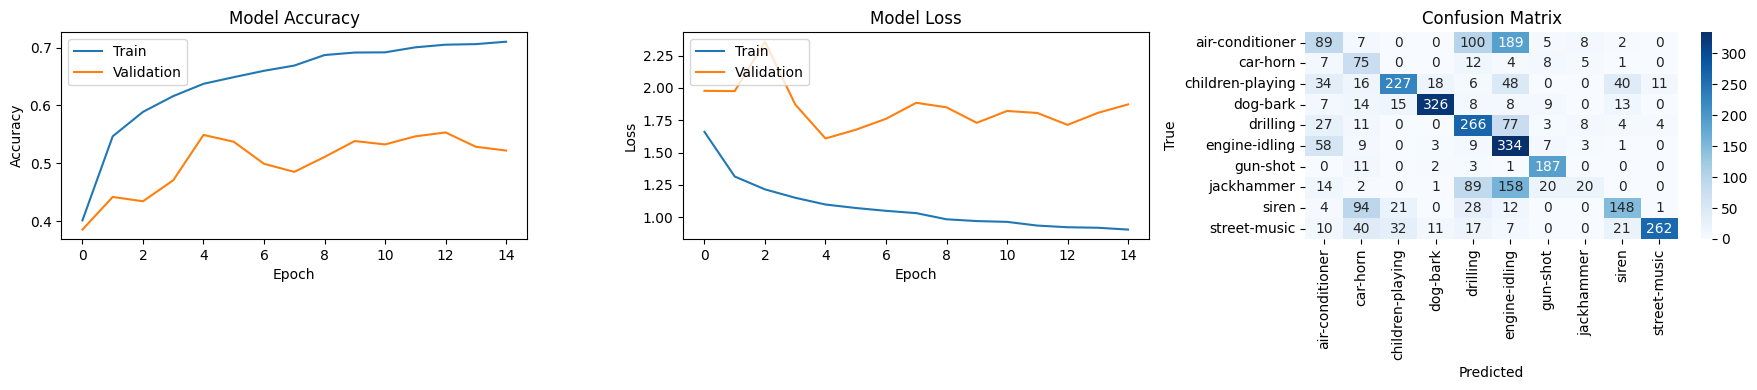

Fold 7 accuracy: 0.5770

=== Training fold 8 (val fold 9) ===
Epoch 1/50
889/889 [==============================] - 97s 107ms/step - loss: 1.6650 - accuracy: 0.4062 - val_loss: 1.7051 - val_accuracy: 0.4445 - lr: 0.0010
Epoch 2/50
889/889 [==============================] - 98s 111ms/step - loss: 1.3373 - accuracy: 0.5413 - val_loss: 1.8335 - val_accuracy: 0.4544 - lr: 0.0010
Epoch 3/50
889/889 [==============================] - 97s 109ms/step - loss: 1.2250 - accuracy: 0.5848 - val_loss: 2.5367 - val_accuracy: 0.4050 - lr: 0.0010
Epoch 4/50
889/889 [==============================] - 97s 109ms/step - loss: 1.1674 - accuracy: 0.6107 - val_loss: 1.1532 - val_accuracy: 0.6615 - lr: 0.0010
Epoch 5/50
889/889 [==============================] - 96s 108ms/step - loss: 1.1275 - accuracy: 0.6293 - val_loss: 1.5194 - val_accuracy: 0.5665 - lr: 0.0010
Epoch 6/50
889/889 [==============================] - 96s 108ms/step - loss: 1.0829 - accuracy: 0.6431 - val_loss: 1.2868 - val_accuracy: 0.6225 - l

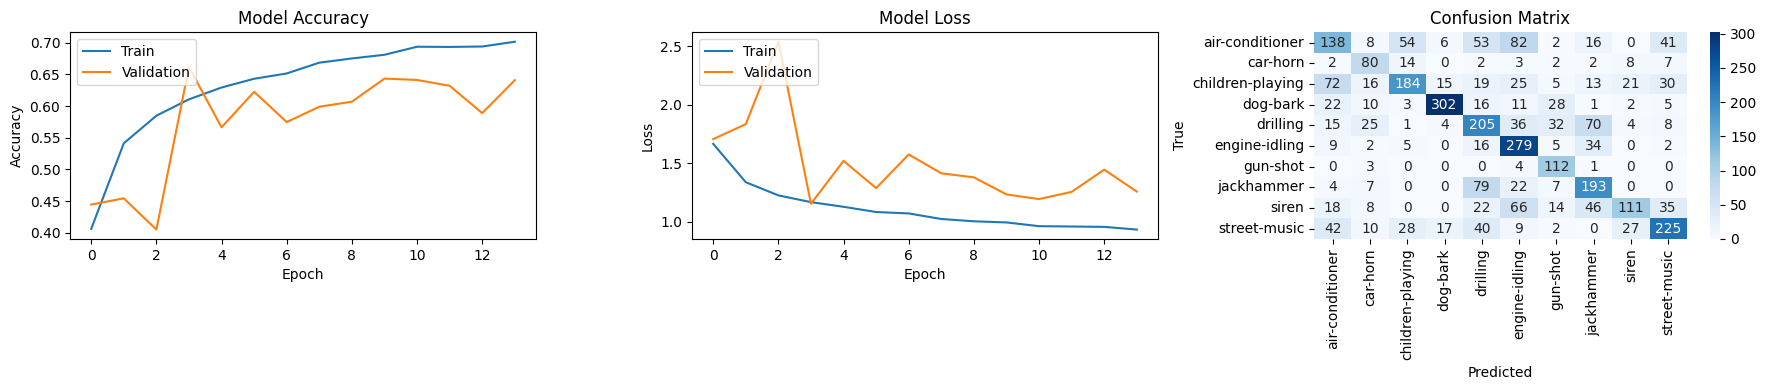

Fold 8 accuracy: 0.5673

=== Training fold 9 (val fold 10) ===
Epoch 1/50
885/885 [==============================] - 99s 110ms/step - loss: 1.7087 - accuracy: 0.3925 - val_loss: 2.2983 - val_accuracy: 0.2712 - lr: 0.0010
Epoch 2/50
885/885 [==============================] - 96s 108ms/step - loss: 1.3615 - accuracy: 0.5302 - val_loss: 1.6606 - val_accuracy: 0.4492 - lr: 0.0010
Epoch 3/50
885/885 [==============================] - 95s 108ms/step - loss: 1.2512 - accuracy: 0.5754 - val_loss: 1.8171 - val_accuracy: 0.4200 - lr: 0.0010
Epoch 4/50
885/885 [==============================] - 95s 107ms/step - loss: 1.1842 - accuracy: 0.6053 - val_loss: 1.5136 - val_accuracy: 0.5108 - lr: 0.0010
Epoch 5/50
885/885 [==============================] - 95s 108ms/step - loss: 1.1512 - accuracy: 0.6176 - val_loss: 1.6188 - val_accuracy: 0.4773 - lr: 0.0010
Epoch 6/50
885/885 [==============================] - 95s 107ms/step - loss: 1.1210 - accuracy: 0.6319 - val_loss: 1.6437 - val_accuracy: 0.5102 - 

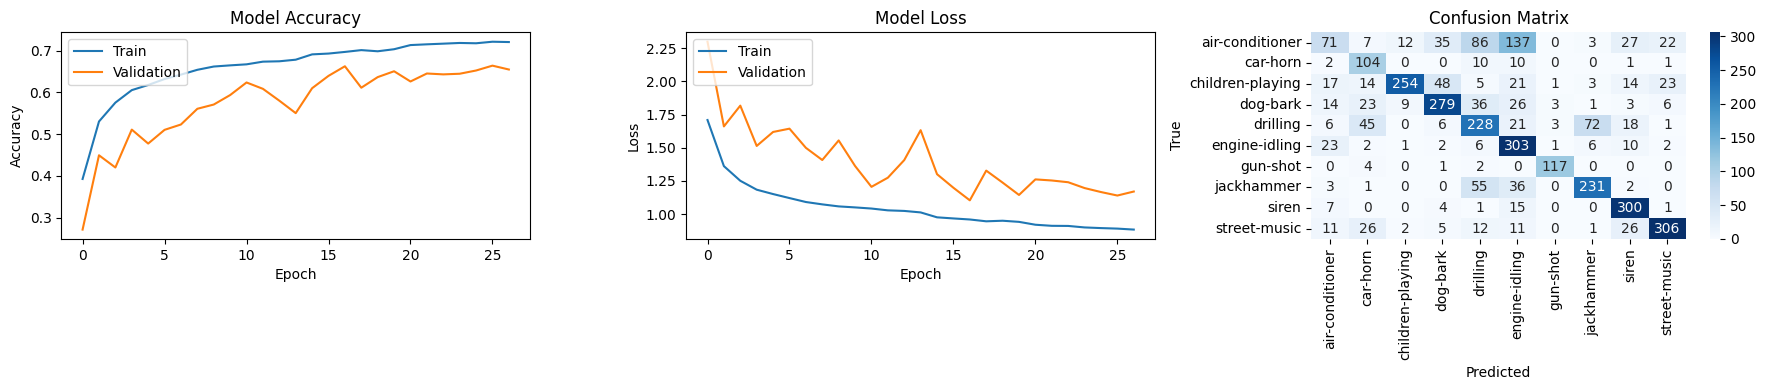

Fold 9 accuracy: 0.6719

=== Training fold 10 (val fold 1) ===
Epoch 1/50
878/878 [==============================] - 101s 114ms/step - loss: 1.6688 - accuracy: 0.4097 - val_loss: 2.2643 - val_accuracy: 0.2941 - lr: 0.0010
Epoch 2/50
878/878 [==============================] - 120s 136ms/step - loss: 1.3294 - accuracy: 0.5479 - val_loss: 1.6310 - val_accuracy: 0.4779 - lr: 0.0010
Epoch 3/50
878/878 [==============================] - 94s 108ms/step - loss: 1.2249 - accuracy: 0.5881 - val_loss: 1.6562 - val_accuracy: 0.4691 - lr: 0.0010
Epoch 4/50
878/878 [==============================] - 94s 107ms/step - loss: 1.1621 - accuracy: 0.6145 - val_loss: 1.7056 - val_accuracy: 0.5112 - lr: 0.0010
Epoch 5/50
878/878 [==============================] - 94s 107ms/step - loss: 1.1296 - accuracy: 0.6273 - val_loss: 1.9510 - val_accuracy: 0.4963 - lr: 0.0010
Epoch 6/50
878/878 [==============================] - 94s 107ms/step - loss: 1.0781 - accuracy: 0.6476 - val_loss: 1.6564 - val_accuracy: 0.5126 

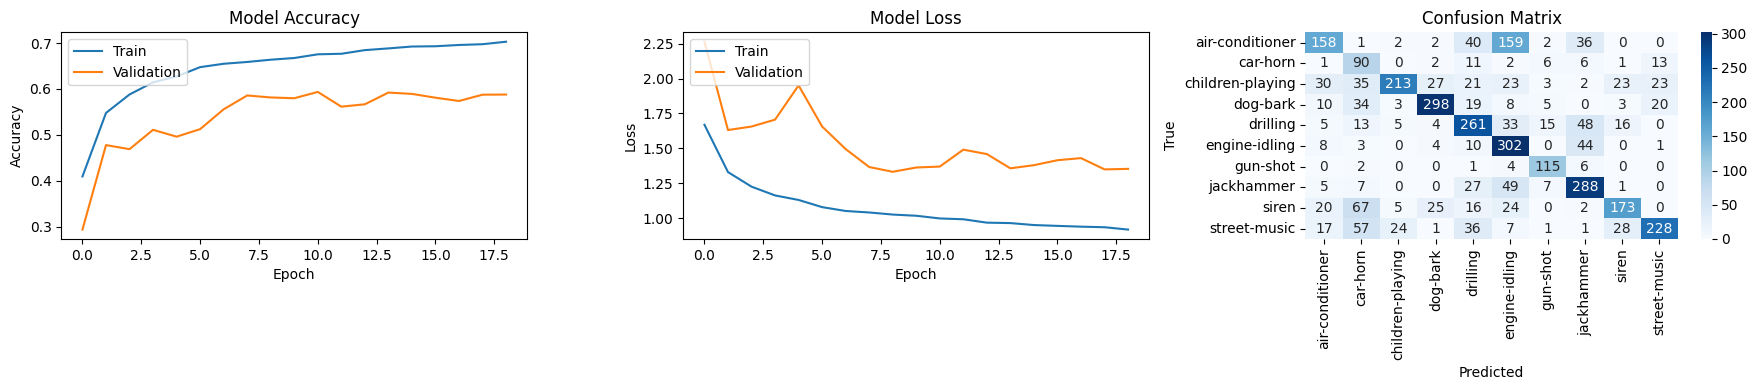

Fold 10 accuracy: 0.6350

Fold accuracies: ['0.6120', '0.6126', '0.5678', '0.5891', '0.6285', '0.6081', '0.5770', '0.5673', '0.6719', '0.6350']

Mean accuracy: 0.6069 ± 0.0314


In [9]:
conf_mat = np.zeros((n_classes, n_classes), dtype=np.int64)

fold_accuracies = []
fold_histories = []

y_true_all = []
y_pred_all = []

# 10-fold cross-validation
for test_fold in range(1, 11):

    val_fold = (test_fold % 10) + 1

    train_idx = np.where((folds != test_fold) & (folds != val_fold))[0]
    val_idx = np.where(folds == val_fold)[0]
    test_idx = np.where(folds == test_fold)[0]

    X_train = X_cnn[train_idx]
    y_train = y[train_idx]

    X_val = X_cnn[val_idx]
    y_val = y[val_idx]

    X_test = X_cnn[test_idx]
    y_test = y[test_idx]

    model = cnn_model(
        input_shape=input_shape,
        n_classes=n_classes,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        l2_reg=l2_reg
    )

    print(f"\n=== Training fold {test_fold} (val fold {val_fold}) ===")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callback_list,
        verbose=1
    )

    fold_histories.append(history.history)

    # Avaliar no test fold
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    plot_graphs(history, y_test, y_pred, class_names)

    fold_acc = np.mean(y_pred == y_test)
    fold_accuracies.append(fold_acc)
    print(f"Fold {test_fold} accuracy: {fold_acc:.4f}")

    cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
    conf_mat += cm

    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())

mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print("\nFold accuracies:", [f"{a:.4f}" for a in fold_accuracies])
print(f"\nMean accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

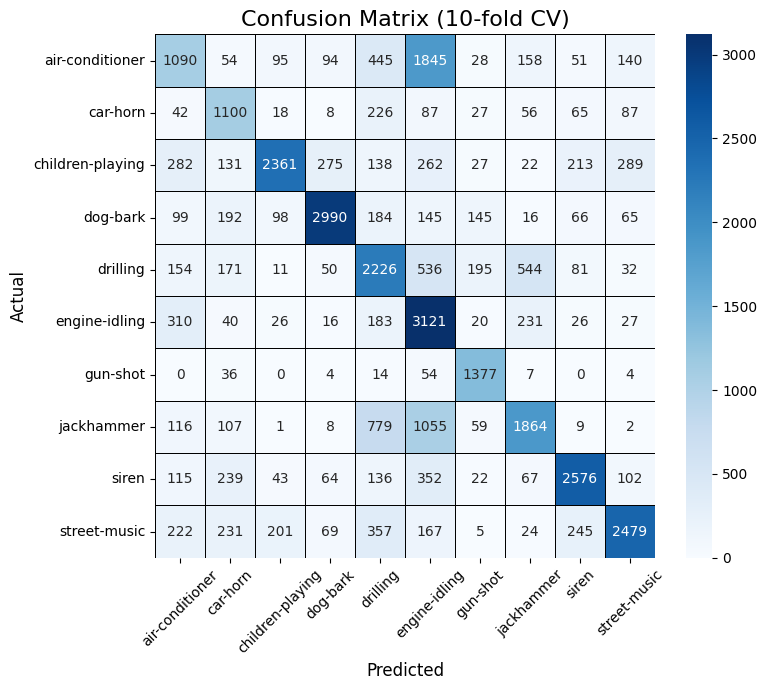

In [10]:
plt.figure(figsize=(8, 7))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="black"
)
plt.title("Confusion Matrix (10-fold CV)", fontsize=16)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    average=None
)

macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
})

df_metrics.loc[len(df_metrics)] = ["Macro-average",
                                   macro_precision,
                                   macro_recall,
                                   macro_f1]

df_metrics

,Class,Precision,Recall,F1
0,air-conditioner,0.448560,0.272500,0.339036
1,car-horn,0.478053,0.641026,0.547672
2,children-playing,0.827260,0.590250,0.688941
3,dog-bark,0.835662,0.747500,0.789126
4,drilling,0.474829,0.556500,0.512431
5,engine-idling,0.409365,0.780250,0.536992
6,gun-shot,0.722835,0.920455,0.809762
7,jackhammer,0.623620,0.466000,0.533410
8,siren,0.773109,0.693219,0.730988
9,street-music,0.768206,0.619750,0.686038
